# Fifa Prediction model

Each training example will be a (22,9) matrix. Each row is a player, the first 11 rows are players from the home team while the last 11 rows are players from the away team. For each player, the following details are used:

1. age
2. is forward
3. is mid fielder
4. is defense
5. is goalkeeper
6. number tournaments
7. appearances
8. goals
9. average time per team

This matrix will be passed to the first layer of the neural network that should predict the 'quality' of each player in the team. There will be a ReLU activation for this network. This will be done by doing:

$$
p = xw^T + b \\
ap = max(0, p)
$$

The output of this will be a (22, 1) matrix. This will then be passed to the team wins prediction portion of the network. This has 1 layer with 121 units with softmax activation as shown below:

$$
L = 1 \\
n^{[1]} = 2 \\
z = apw + b \\
y = softmax(z)
$$

The goal is to get a model that surpasses the following benchmarks:
- 75.42% accuracy on predicting a win
- 18% accuracy for predicting exact scores

In [355]:
# Imports
import numpy as np
import numpy.typing as npt
from sklearn.model_selection import train_test_split
import math
import matplotlib.pyplot as plt

In [320]:
def f_x(
    players: npt.NDArray, 
    w_p: npt.NDArray, 
    b_p: float, 
    w_t: npt.NDArray, 
    b_t: float
):
    """ 
    Function that will do a forward pass for a single training example in the example above.
    
    Args:
        players (ndarray) - a (22,9) numpy array with 9 features for 22 players from the home and away team
        w_p (ndarray) - a (1,9) numpy array with weights for player predictions
        b_p (scalar) - bias for player quality prediction
        w_t (ndarray) - a (121, 22) numpy array with the weights for the team score prediction
        b_t (scalar) - bias for the team score prediction
        
    Returns:
        scores (ndarray) - a (121,1) numpy array with probability of each of the score distributions
        z_t (ndarray) - cached z_t value
        a_p (ndarray) - cached a_t value,
        z_p (ndarray) - cached z_p value
    """
    z_p = np.matmul(players, w_p.T) + b_p
    a_p = np.maximum(0, z_p)
    z_t = np.matmul(w_t, a_p) + b_t
    shifted_logits = z_t - np.max(z_t, axis=0, keepdims=True)
    e_zi = np.exp(shifted_logits)
    a_t = e_zi / np.sum(e_zi, axis=0, keepdims=True)
    return (a_t, z_t, a_p, z_p)
    

In [321]:
# Forward pass is working
players_1 = np.ones((1, 9))
players_1 = np.tile(players_1, (22, 1))
w_p = np.ones((1, 9))
b_p = 0
w_t = np.ones((121, 22))
b_t = 0
result_1 = f_x(
    players_1,
    w_p,
    b_p,
    w_t,
    b_t
)
print(result_1[0])

[[0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00826446]
 [0.00

In [322]:
def L(y_pred, y):
    """
    Returns the means squared error of a single example
    
    Args:
        y_pred (ndarray) - predicted home away goal scores
        y (ndarray) - actual home away goal scores
        
    Returns:
        error (scalar) - mean squared error loss
    """
    loss = np.where(y == 1, -np.log(y_pred + 1e-15), 0) # Adding by a small number to prevent trying to get log of 0
    return np.sum(loss)

In [323]:
print(L(np.array([0.778,0.232]), np.array([1,0])))

0.25102875480374415


In [324]:
def calculate_gradients(
    X: npt.NDArray, 
    w_p: npt.NDArray, 
    b_p: float, 
    w_t: npt.NDArray, 
    b_t: float,
    Y: npt.NDArray
):
    """ 
    Function to calculate the gradients used in gradient descent
    
    Args:
        X (ndarray) - a (m,22,9) array with m training examples
        Y (ndarray) - a (m, 121, 1) array with labels for m training examples
        w_p (ndarray) - weights for the player section of neural network
        b_p (scalar) - bias for the player section of neural network
        w_t (ndarray) - weights for team section of neural network
        b_t (scalar) - bias for team section of neural network
        
    Returns:
        gradients (list) - list of gradients of parameters
    """
    dw_t = np.zeros(w_t.shape)
    db_t = 0
    dw_p = np.zeros(w_p.shape)
    db_p = 0
    J = 0
    
    m = X.shape[0]
    
    # For each training example
    for i in range(m):
        # Get the prediction
        x_i = X[i]
        y_i = Y[i]
        (y_pred_i, z_t_i, a_p_i, z_p_i) = f_x(
            x_i,
            w_p,
            b_p,
            w_t,
            b_t
        )
        
        
        # Get derivative
        # da_t_i = 2 * (y_pred_i - y_i)
        dz_t_i = y_pred_i - y_i
        dw_t += a_p_i.T * dz_t_i
        db_t += np.sum(dz_t_i)
        da_p_i = np.matmul(w_t.T, dz_t_i)
        dz_p_i = np.where(z_p_i < 0, 0, da_p_i)
        dw_p += np.matmul(dz_p_i.T, x_i)
        db_p += np.sum(dz_p_i)
        
        # Add loss 
        J += L(y_pred_i, y_i)
        
        
    dw_t /= m
    db_t /= m
    dw_p /= m
    db_p /= m
    J /= m
    return (dw_p, db_p, dw_t, db_t, J)

In [325]:
x_train_1 = np.ones((1, 9))
x_train_1 = np.tile(x_train_1, (22, 1))
w_p = np.ones((1, 9))
b_p = 0
w_t = np.ones((121, 22))
b_t = 0
X_train = np.array([
    x_train_1
])
Y_train = np.zeros((121, 1))
Y_train[0][0] = 1

print(calculate_gradients(
    X_train,
    w_p,
    b_p,
    w_t,
    b_t,
    Y_train
))

(array([[-2640., -2640., -2640., -2640., -2640., -2640., -2640., -2640.,
        -2640.]]), np.float64(-2639.9999999999986), array([[-8.92561983, -8.92561983, -8.92561983, ..., -8.92561983,
        -8.92561983, -8.92561983],
       [-8.92561983, -8.92561983, -8.92561983, ..., -8.92561983,
        -8.92561983, -8.92561983],
       [-8.92561983, -8.92561983, -8.92561983, ..., -8.92561983,
        -8.92561983, -8.92561983],
       ...,
       [-8.92561983, -8.92561983, -8.92561983, ..., -8.92561983,
        -8.92561983, -8.92561983],
       [-8.92561983, -8.92561983, -8.92561983, ..., -8.92561983,
        -8.92561983, -8.92561983],
       [-8.92561983, -8.92561983, -8.92561983, ..., -8.92561983,
        -8.92561983, -8.92561983]], shape=(121, 22)), np.float64(-120.00000000000001), np.float64(580.2906560171909))


In [326]:
# Splitting data into train / cross-validation / test sets
X = np.load("data/players_batch_6_2026-05-25 21:44:14.801126.npy")
Y = np.load("data/results_batch_6_2026-05-25 21:44:14.801174.npy")
X_train, X_mid, Y_train, Y_mid = train_test_split(X, Y, test_size=0.2, random_state=42)
X_cv, X_test, Y_cv, Y_test = train_test_split(X_mid, Y_mid, test_size=0.5, random_state=42)
print(X_train.shape, X_cv.shape, X_test.shape)
print(Y_train.shape, Y_cv.shape, Y_test.shape)

(560, 22, 9) (70, 22, 9) (70, 22, 9)
(560, 121, 1) (70, 121, 1) (70, 121, 1)


In [327]:
# Scale features
mean = np.mean(X_train, axis=(0,1), keepdims=True)
std = np.std(X_train, axis=(0,1), keepdims=True)
std = np.where(std == 0, 1.0, std)

X_train_scaled = (X_train - mean) / std
X_cv_scaled = (X_cv - mean) / std
X_test_scaled = (X_test - mean) / std
print(X_train_scaled.shape)
print(X_cv_scaled.shape)
print(X_test_scaled.shape)

(560, 22, 9)
(70, 22, 9)
(70, 22, 9)


In [370]:
def gradient_descent(
    X: npt.NDArray, 
    w_p: npt.NDArray, 
    b_p: float, 
    w_t: npt.NDArray, 
    b_t: float,
    Y: npt.NDArray,
    alpha: float,
    num_iters: int,
    J_n: int = 10
):
    """ 
    This function will minimize the cost of the model using gradient descent and return found weights
    
    Args:
        X (ndarray) - a (m, 22, 9) array serving as input to model
        w_p (ndarray) - a (1,9) array with the initial weights of the player section of model
        b_p (scalar) - initial bias for player section of model
        w_t (ndarray) - a (2,22) array with initial weights of the team section of model
        b_t (scalar) - initial bias for team section of model
        Y (ndarray) - a (m, 2, 1) array with target outputs for model
        alpha (scalar) - learning rate
        num_iters (scalar) - number of times to run gradient descent
        J_n (scalar) - interval to store training example
        
    Return:
        w_p (ndarray) - a (1, 9) array that minimizes cost
        b_p (scalar) - bias that minimized cost
        w_t (ndarray) - a (2, 22) array that minimizes cost
        b_t (scalar) - bias that minimizes cost
        Js (list) - list of training costs and epoch at different iterations of training
    """
    Js = []
    for epoch in range(num_iters):
        # Get derivatives
        (dw_p, db_p, dw_t, db_t, J) = calculate_gradients(
            X=X,
            w_p=w_p,
            b_p=b_p,
            w_t=w_t,
            b_t=b_t,
            Y=Y
        )
        
        # Update weights
        w_p = w_p - (alpha * dw_p)
        w_t = w_t - (alpha * dw_t)
        b_p = b_p - (alpha * db_p)
        b_t = b_t - (alpha * db_t)
        
        # Print result
        print(f"Cost at epoch {epoch}/{num_iters} = {J}")
        
        if epoch % J_n == 0 or epoch == num_iters - 1:
            Js.append((epoch, J))
        
    return (w_p, w_t, b_p, b_t, Js)

In [371]:
# Confirm that gradient descent is working
# Get initial weights
w_t = np.random.rand(121, 22)
w_p = np.random.rand(1, 9)
b_p = 0
b_t = 0

# Run gradient descent
(new_w_p, new_w_t, new_b_p, new_bt, J_train_s) = gradient_descent(
    X=X_train_scaled,
    w_p=w_p,
    w_t=w_t,
    b_p=b_p,
    b_t=b_t,
    Y=Y_train,
    alpha=0.01,
    num_iters=100
)

Cost at epoch 0/100 = 7.325177619314147
Cost at epoch 1/100 = 7.174951417956318
Cost at epoch 2/100 = 7.0332467584256335
Cost at epoch 3/100 = 6.899746132994949
Cost at epoch 4/100 = 6.77410810360662
Cost at epoch 5/100 = 6.655975822491182
Cost at epoch 6/100 = 6.544820158405398
Cost at epoch 7/100 = 6.440421238648898
Cost at epoch 8/100 = 6.342246819787403
Cost at epoch 9/100 = 6.249932888389859
Cost at epoch 10/100 = 6.163225048419723
Cost at epoch 11/100 = 6.081622563935045
Cost at epoch 12/100 = 6.004781111290585
Cost at epoch 13/100 = 5.932578962844539
Cost at epoch 14/100 = 5.864606023594282
Cost at epoch 15/100 = 5.800791224206442
Cost at epoch 16/100 = 5.740951655841813
Cost at epoch 17/100 = 5.684918833882422
Cost at epoch 18/100 = 5.6323991141604575
Cost at epoch 19/100 = 5.583080862164279
Cost at epoch 20/100 = 5.536633938919309
Cost at epoch 21/100 = 5.4930379180107325
Cost at epoch 22/100 = 5.4522080050683375
Cost at epoch 23/100 = 5.413822668089222
Cost at epoch 24/100 = 

Cost at epoch 0/1000 = 5.712860881504797
Cost at epoch 1/1000 = 5.7081989420261285
Cost at epoch 2/1000 = 5.703567263505627
Cost at epoch 3/1000 = 5.698964008015646
Cost at epoch 4/1000 = 5.694385133419823
Cost at epoch 5/1000 = 5.689832092652019
Cost at epoch 6/1000 = 5.685309534761565
Cost at epoch 7/1000 = 5.6808124499270845
Cost at epoch 8/1000 = 5.676343405451051
Cost at epoch 9/1000 = 5.671902544582235
Cost at epoch 10/1000 = 5.667488741818104
Cost at epoch 11/1000 = 5.663103229088506
Cost at epoch 12/1000 = 5.65874459195357
Cost at epoch 13/1000 = 5.6544121070717255
Cost at epoch 14/1000 = 5.650106402022665
Cost at epoch 15/1000 = 5.6458302852103985
Cost at epoch 16/1000 = 5.641581817108316
Cost at epoch 17/1000 = 5.6373565270252
Cost at epoch 18/1000 = 5.633157195670402
Cost at epoch 19/1000 = 5.628983174141399
Cost at epoch 20/1000 = 5.6248349863113205
Cost at epoch 21/1000 = 5.6207124681974445
Cost at epoch 22/1000 = 5.616615412662899
Cost at epoch 23/1000 = 5.612545148343742

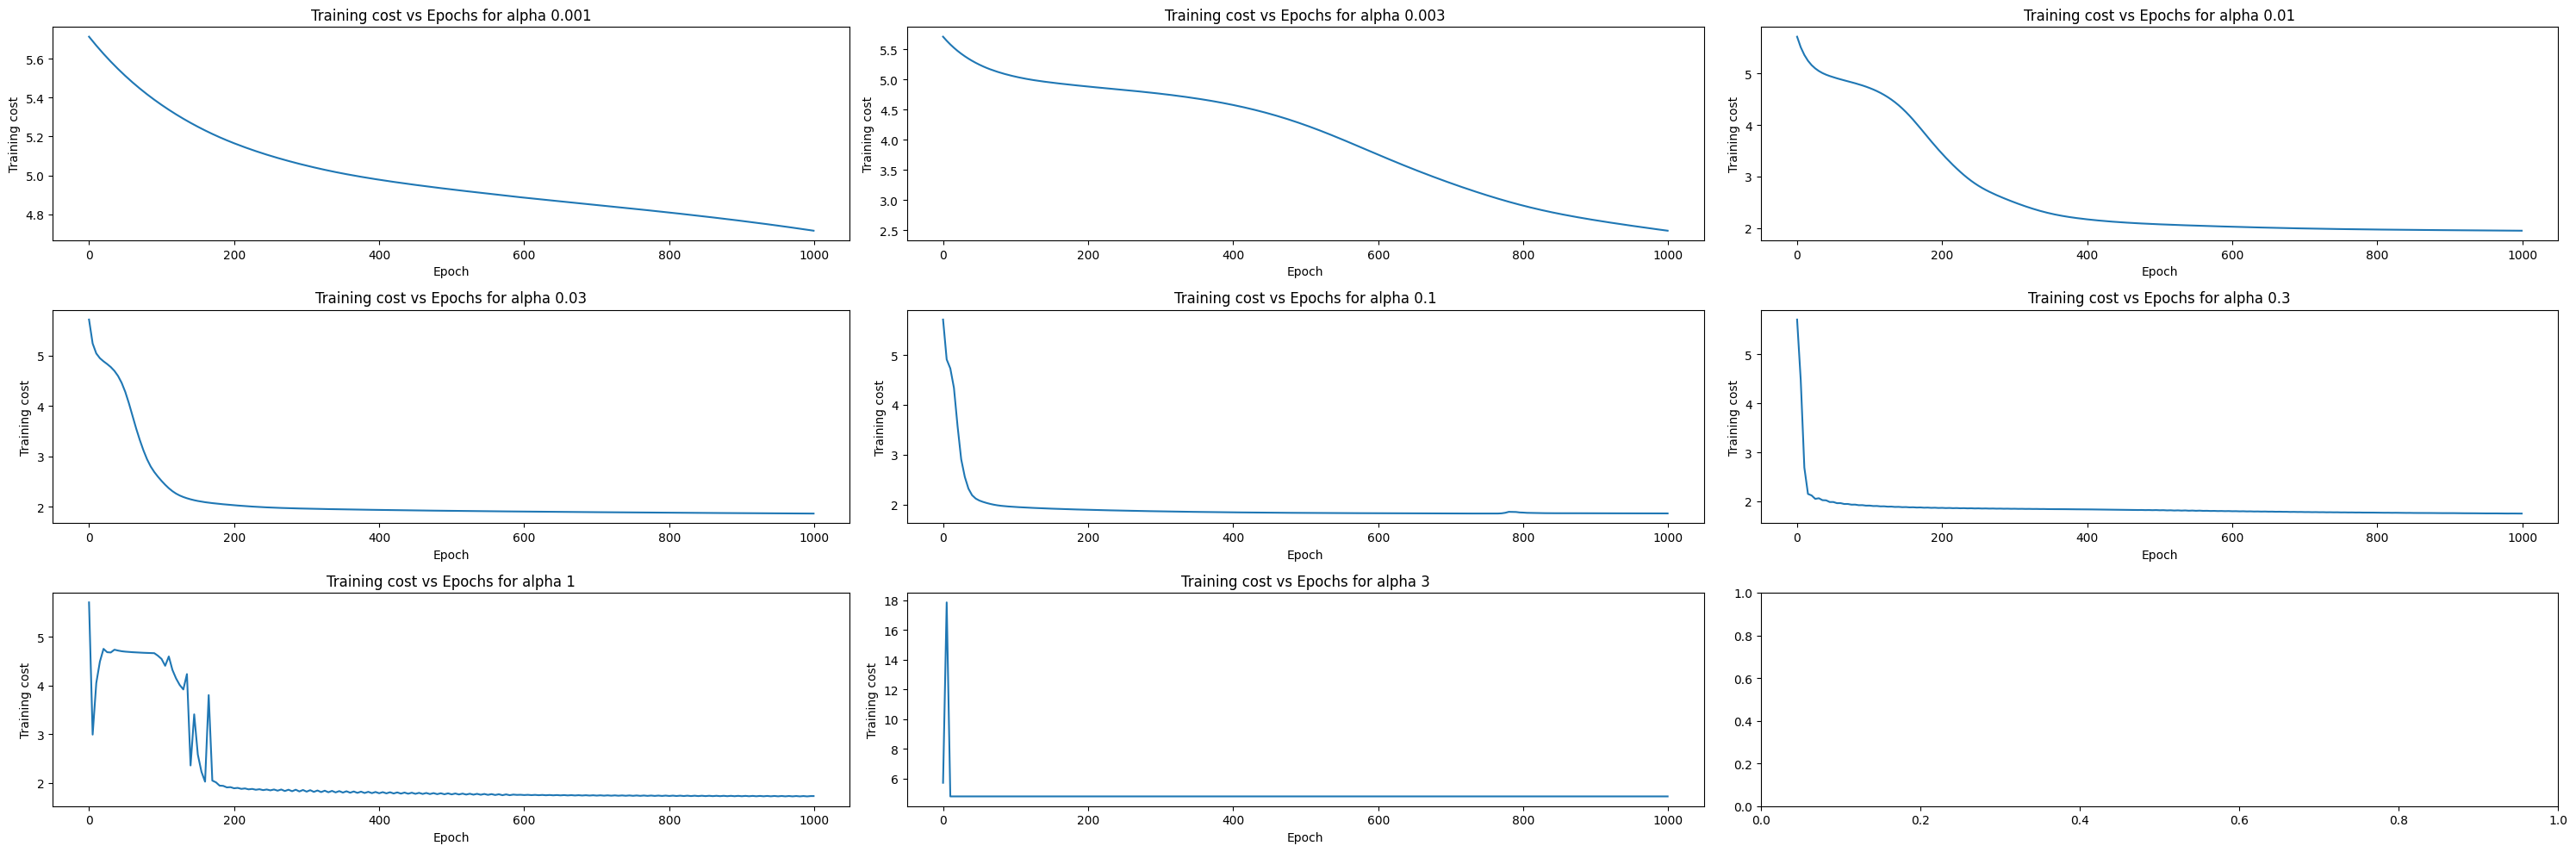

In [373]:
# Look for the best alpha value
# Get initial weights
w_t = np.random.rand(121, 22)
w_p = np.random.rand(1, 9)
b_p = 0
b_t = 0

# Alpha values to try
alphas = [0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1, 3]

fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(30,10))
print
for i in range(len(alphas)):
    # Run gradient descent for each value of alpha with the same initial weights
    # Run gradient descent
    alpha = alphas[i]
    (_, _, _, _, J_train_s) = gradient_descent(
        X=X_train_scaled,
        w_p=w_p,
        w_t=w_t,
        b_p=b_p,
        b_t=b_t,
        Y=Y_train,
        alpha=alpha,
        num_iters=1000,
        J_n=5
    )
    
    epochs = [x[0] for x in J_train_s]
    Js = [y[1] for y in J_train_s]
    
    row = math.floor(i / 3)
    column = i % 3
    
    axs[row][column].plot(epochs, Js)
    axs[row][column].set_xlabel("Epoch")
    axs[row][column].set_ylabel("Training cost")
    axs[row][column].set_title(f"Training cost vs Epochs for alpha {alphas[i]}")


plt.tight_layout()
plt.show()

In [378]:
# Seems that an alpha of 0.3 is the best and it converges at around 1000 epochs. Initialize model with different weights, train with the found hyperparameters above and pick the 
# best model
lowest_J_train = np.inf
new_w_p = np.array([])
new_w_t = np.array([])
new_b_p = np.array([])
new_bt = np.array([]),

for attempts in range(5):
    # Get initial weights
    w_t = np.random.rand(121, 22)
    w_p = np.random.rand(1, 9)
    b_p = 0
    b_t = 0

    # Run gradient descent
    (temp_new_w_p, temp_new_w_t, temp_new_b_p, temp_new_bt, J_train_s) = gradient_descent(
        X=X_train_scaled,
        w_p=w_p,
        w_t=w_t,
        b_p=b_p,
        b_t=b_t,
        Y=Y_train,
        alpha=0.3,
        num_iters=1000
    )
    
    # If cost is lower than lowest found J_train update weights found
    found_J_train = J_train_s[-1][1]
    if found_J_train < lowest_J_train:
        print(f"Lower J_train found {found_J_train}")
        lowest_J_train = found_J_train
        new_w_p = temp_new_w_p
        new_w_t = temp_new_w_t
        new_b_p = temp_new_b_p
        new_bt = temp_new_bt 

Cost at epoch 0/1000 = 7.769926068659678
Cost at epoch 1/1000 = 5.0242892472984835
Cost at epoch 2/1000 = 4.919054496656196
Cost at epoch 3/1000 = 4.8798708553214425
Cost at epoch 4/1000 = 4.855707077036497
Cost at epoch 5/1000 = 4.838506891910931
Cost at epoch 6/1000 = 4.824837514456981
Cost at epoch 7/1000 = 4.8139703985515485
Cost at epoch 8/1000 = 4.804804949407642
Cost at epoch 9/1000 = 4.797109702644678
Cost at epoch 10/1000 = 4.790023950395565
Cost at epoch 11/1000 = 4.781479001790058
Cost at epoch 12/1000 = 4.770603188006816
Cost at epoch 13/1000 = 4.753946133814672
Cost at epoch 14/1000 = 4.723399894058923
Cost at epoch 15/1000 = 4.663254601541523
Cost at epoch 16/1000 = 4.590753386678789
Cost at epoch 17/1000 = 4.486956809543032
Cost at epoch 18/1000 = 4.341045778260498
Cost at epoch 19/1000 = 4.154796529103415
Cost at epoch 20/1000 = 3.9446307610939164
Cost at epoch 21/1000 = 3.733598748694485
Cost at epoch 22/1000 = 3.5198049815510917
Cost at epoch 23/1000 = 3.3005606586408

In [379]:
print(f"Lowest training cost found is {lowest_J_train}")

Lowest training cost found is 1.6972761113524337


In [359]:
def J(
    X: npt.NDArray, 
    w_p: npt.NDArray, 
    b_p: float, 
    w_t: npt.NDArray, 
    b_t: float,
    Y: npt.NDArray
):
    """ 
    Evaluate model on dataset
    
    Args:
        X (ndarray) - a (m,22,9) array with m examples
        Y (ndarray) - a (m, 2, 1) array with labels for m examples
        w_p (ndarray) - weights for the player section of neural network
        b_p (scalar) - bias for the player section of neural network
        w_t (ndarray) - weights for team section of neural network
        b_t (scalar) - bias for team section of neural network
    """
    J = 0
    m = X.shape[0]
    
    # For each training example
    for i in range(m):
        # Get the prediction
        x_i = X[i]
        y_i = Y[i]
        (y_pred_i, _, _, _) = f_x(
            x_i,
            w_p,
            b_p,
            w_t,
            b_t
        )
        
        # Add loss 
        J += L(y_pred_i, y_i)
        
    J /= m
    print(f"Cost is {J}")
    

In [380]:
J(
    X=X_cv,
    w_p=new_w_p,
    b_p=new_b_p,
    w_t=new_w_t,
    b_t=new_bt,
    Y=Y_cv
)

Cost is 22.335967136720996


In [332]:
def interpret_probabilities(prob):
    """ 
    Function to interpret the returned probabilities by the model
    
    Args:
        prob (ndarray) - array with probabilities for different match results
        
    Returns:
        scores (str) - human readable version of prediction
    """
    predicted = np.argmax(prob)
    home_score = math.floor(predicted / 11)
    away_score = predicted % 11
    return f"{home_score}-{away_score}"

In [381]:
prob = f_x(
    X_cv_scaled[5],
    new_w_p,
    new_b_p,
    new_w_t,
    new_bt
)[0]

predicted_score = interpret_probabilities(prob)
actual_score = interpret_probabilities(Y_cv[5])
print(f"Predicted score is {predicted_score} while actual is {actual_score}")

Predicted score is 2-0 while actual is 5-0


In [382]:
def accuracy_score(y_pred, y_label):
    """ 
    Return the ratio of correct responses across the entire test set.add
    
    Args:
        y_pred (ndarray): (m, 121, 1) array with predictions for each class from the model from the model
        y_label(ndarray): (m, 121, 1) array with the actual labels
        
    Returns:
        accuracy (scalar): ratio of correct responses to all responses
    """
    predictions = np.argmax(y_pred, axis=1)
    actual = np.argmax(y_label, axis=1)
    num_correct = np.sum(predictions == actual)
    return num_correct / y_pred.shape[0]

In [383]:
def predict(
    X: npt.NDArray, 
    w_p: npt.NDArray, 
    b_p: float, 
    w_t: npt.NDArray, 
    b_t: float,
):
    """ 
    Make prediction for all of the examples in the passed dataset
    
    Args:
        X (ndarray) - a (m,22,9) array with m examples
        w_p (ndarray) - weights for the player section of neural network
        b_p (scalar) - bias for the player section of neural network
        w_t (ndarray) - weights for team section of neural network
        b_t (scalar) - bias for team section of neural network
        
    Returns:
        Y_pred (ndarray) - a (m, 121, 1) array with prediction of all examples in X
    """
    m = X.shape[0]
    predictions = []
    
    for i in range(m):
        x_i = X[i]
        (pred, _, _, _) = f_x(
            x_i,
            w_p,
            b_p,
            w_t,
            b_t
        )
        predictions.append(pred)
        
    Y_pred = np.array(predictions)
    return Y_pred

In [384]:
y_pred = predict(
    X_cv_scaled,
    new_w_p,
    new_b_p,
    new_w_t,
    new_bt
)
accuracy = accuracy_score(y_pred, Y_cv)
print(f"Accuracy of model is {accuracy}")

Accuracy of model is 0.18571428571428572


In [337]:
class PredictionRecall:
    def __init__(self, t_p: int, f_p: int, f_n:int, total: int, label: str):
        """ 
        Return object with prediction recall values
        
        Args:
            label (str): Name of the class
            t_p (int): Total true positive for the given label
            f_p (int): Total false positives for given label
            total (int): Total items with given label
            f_n (int): Total false negatives for given label
        """
        self.total = total
        self.t_p = t_p
        self.f_p = f_p
        self.f_n = f_n
        self.label = label
        
    def __repr__(self):
        return f"{self.label} with t_p: {self.t_p}, f_p: {self.f_p}, f_n: {self.f_n} and total: {self.total}"

def get_precision_recall(y_pred, y_label) -> list[PredictionRecall]:
    """ 
    Returns the precision and recall of the model based on the predictions it has made
    
    Args:
        y_pred (ndarray) - a (m, 121, 1) array with the predictions of the model
        y_label (ndarray) - a (m, 121, 1) array with the actual values
        
    Returns:
        prediction_recall (list) - list of prediction recall values
    """
    predictions = [interpret_probabilities(prob) for prob in y_pred]
    actual = [interpret_probabilities(prob) for prob in y_label]
    all_items = predictions.copy()
    all_items.extend(actual)
    labels = set(all_items)
    
    m = len(actual)
    precisions = []
    
    for label in labels:
        total = 0
        false_positive = 0
        false_negative = 0
        true_positive = 0
        
        for i in range(m):
            entry = actual[i]
            pred = predictions[i]
            
            if entry == label:
                total += 1
                
            if entry == label and pred == entry:
                true_positive += 1
            elif entry != label and pred == label:
                false_positive += 1
        false_negative = total - true_positive
        
        precisions.append(PredictionRecall(
            t_p=true_positive,
            f_p=false_positive,
            f_n=false_negative,
            total=total,
            label=label
        ))
    
    return precisions
    

In [338]:
precisions = get_precision_recall(
    y_pred=np.array([
        [
            [0],
            [0],
            [0]
        ],
        [
            [0],
            [0],
            [0]
        ],
        [
            [0],
            [0],
            [0]
        ],
        [
            [0],
            [0],
            [0]
        ],
        [
            [0],
            [0],
            [0]
        ],
        [
            [0],
            [0],
            [0]
        ],
        [
            [0],
            [0],
            [0]
        ],
        [
            [0],
            [0],
            [0]
        ],
        [
            [0],
            [0],
            [0]
        ]]),
    y_label=np.array([
        [
            [0],
            [0],
            [0]
        ],
        [
            [0],
            [0],
            [0]
        ],
        [
            [0],
            [1],
            [0]
        ],
        [
            [0],
            [0],
            [2]
        ],
        [
            [0],
            [1],
            [0]
        ],
        [
            [0],
            [1],
            [0]
        ],
        [
            [0],
            [0],
            [2]
        ],
        [
            [0],
            [0],
            [0]
        ],
        [
            [0],
            [1],
            [0]
        ]]),
)
print(precisions)

[0-2 with t_p: 0, f_p: 0, f_n: 2 and total: 2, 0-1 with t_p: 0, f_p: 0, f_n: 4 and total: 4, 0-0 with t_p: 3, f_p: 6, f_n: 0 and total: 3]


In [385]:
def precision_recall(y_pred, y_label):
    """ 
        Print precision recall for model predictions
        
        Args:
            y_pred (ndarray): a (m, 121, 1) array with the predictions of the model
            y_label (ndarray): a (m, 121, 1) array with labels of the model
    """ 
    precisions = get_precision_recall(y_pred=y_pred, y_label=y_label)
    
    # Order precisions by totals
    n = len(precisions)
    for i in range(n):
        swapped = False
        
        for j in range(0, n-i-1):
            # Traverse array from 0 to n - i - 1
            # Swap if the element found is lesser than next element
            if precisions[j].total < precisions[j+1].total:
                precisions[j], precisions[j + 1] = precisions[j + 1], precisions[j]
                swapped = True
        
        if (swapped == False):
            break
    
    
    print(f"    Precision and recall")
    for prec in precisions:
        precision = 0 if prec.f_p + prec.t_p == 0 else (prec.t_p / (prec.f_p + prec.t_p))
        recall = 0 if prec.t_p + prec.f_n == 0 else (prec.t_p) / (prec.t_p + prec.f_n)
        p_1 = 0 if precision == 0 else 1 / precision
        r_1 = 0 if recall == 0 else 1 / recall
        f1_score = 1 / 0.5 * (p_1 + r_1)
        print(f"{prec.label.center(5)}  TP:{prec.t_p}  FP:{prec.f_p}  FN:{prec.f_n}: Prec:{precision:.4f}  Rec:{recall:.4f}  F1:{f1_score:.4f}  Total:{prec.total}")

In [386]:
precision_recall(y_pred=y_pred, y_label=Y_cv)

    Precision and recall
 2-0   TP:7  FP:18  FN:13: Prec:0.2800  Rec:0.3500  F1:12.8571  Total:20
 1-0   TP:0  FP:2  FN:14: Prec:0.0000  Rec:0.0000  F1:0.0000  Total:14
 4-0   TP:0  FP:2  FN:13: Prec:0.0000  Rec:0.0000  F1:0.0000  Total:13
 3-0   TP:5  FP:26  FN:6: Prec:0.1613  Rec:0.4545  F1:16.8000  Total:11
 5-0   TP:0  FP:3  FN:6: Prec:0.0000  Rec:0.0000  F1:0.0000  Total:6
 0-0   TP:1  FP:4  FN:4: Prec:0.2000  Rec:0.2000  F1:20.0000  Total:5
 6-0   TP:0  FP:1  FN:1: Prec:0.0000  Rec:0.0000  F1:0.0000  Total:1
 7-0   TP:0  FP:1  FN:0: Prec:0.0000  Rec:0.0000  F1:0.0000  Total:0


In [341]:
# Debugging f_x
print(w_p)

[[0.4067726  0.43369758 0.95030238 0.25948957 0.9568529  0.75353082
  0.08508242 0.44334554 0.18288143]]


In [342]:
print(new_w_p)
print(new_w_p.shape)

[[ 0.2518581   0.29707481  0.82908768  0.12194343  1.3697132   0.376473
  -0.08908276  0.15989664  0.14736108]]
(1, 9)


In [343]:
print(new_b_p)

0.08828491712619789


In [344]:
print(w_t)

[[9.38264626e-01 9.71831648e-01 7.86360819e-01 ... 2.99410340e-04
  3.95489231e-01 5.29629761e-01]
 [6.50776423e-01 8.08195637e-01 5.32509125e-01 ... 2.62273739e-01
  4.60402807e-01 9.09344528e-01]
 [5.63929087e-01 4.70508244e-01 4.72849022e-01 ... 2.66511949e-02
  1.68893165e-01 7.85001548e-01]
 ...
 [4.91477432e-01 6.38436717e-01 2.66870824e-01 ... 1.02897320e-01
  8.09749263e-02 2.24315297e-01]
 [9.23665848e-01 2.54398856e-01 8.67498666e-01 ... 5.44636904e-01
  3.85787344e-01 7.91209785e-01]
 [3.61873786e-01 9.44055977e-01 6.88955320e-01 ... 5.83196546e-01
  6.90214932e-01 1.92616424e-01]]


In [345]:
print(new_w_t)

[[1.1277053  0.9735855  0.79370661 ... 0.02030769 0.44375401 0.54985303]
 [0.61466219 0.80588409 0.53036158 ... 0.25883448 0.45038784 0.90221306]
 [0.54814648 0.46968931 0.47205485 ... 0.02557759 0.16580593 0.7822021 ]
 ...
 [0.48378476 0.63778059 0.26635689 ... 0.10234808 0.07972299 0.22373697]
 [0.91232888 0.25412026 0.86679493 ... 0.54355622 0.38385046 0.78973393]
 [0.3562019  0.94344805 0.68834035 ... 0.58249179 0.6884219  0.19211453]]


In [346]:
print(new_bt)

-1.8867560281253547e-18


In [347]:
example = X_cv_scaled[5]
print(example)

[[ 1.99280815e-01 -5.31788336e-01 -7.16858058e-01 -8.06865475e-01
   3.12557687e+00 -6.30667579e-01 -3.47737832e-02 -7.20536566e-01
  -8.80149937e-03]
 [ 1.99280815e-01 -5.31788336e-01 -7.16858058e-01  1.23936397e+00
  -3.19940939e-01 -6.30667579e-01  4.41017644e-01 -5.64417802e-01
   2.75347935e-02]
 [-3.45458399e-01 -5.31788336e-01 -7.16858058e-01  1.23936397e+00
  -3.19940939e-01 -6.30667579e-01 -1.46287399e-01 -2.91209965e-01
  -4.91751582e-02]
 [-3.45458399e-01 -5.31788336e-01  1.39497630e+00 -8.06865475e-01
  -3.19940939e-01 -6.30667579e-01  3.21343863e-02  4.11324473e-01
   1.12319477e-01]
 [ 1.28875924e+00 -5.31788336e-01 -7.16858058e-01  1.23936397e+00
  -3.19940939e-01 -6.30667579e-01  3.22069787e-01 -2.71695120e-01
   7.34796414e-03]
 [ 1.28875924e+00 -5.31788336e-01 -7.16858058e-01  1.23936397e+00
  -3.19940939e-01 -6.30667579e-01  5.22794296e-01 -5.25388111e-01
  -7.26767615e-04]
 [-6.17828006e-01 -5.31788336e-01  1.39497630e+00 -8.06865475e-01
  -3.19940939e-01 -6.3066757

In [348]:
pred, z_t, a_p, z_p = f_x(
    example,
    new_w_p,
    new_b_p,
    new_w_t,
    new_bt
)

In [349]:
print(pred)
print(interpret_probabilities(pred))
print(interpret_probabilities(Y_cv[5]))

[[1.73716117e-02]
 [7.33140313e-03]
 [3.94223475e-03]
 [1.28780459e-04]
 [5.69301678e-05]
 [5.86382896e-03]
 [1.91466536e-03]
 [7.80879504e-03]
 [2.18215073e-03]
 [3.73316092e-03]
 [2.48893191e-04]
 [1.00099497e-01]
 [5.03014079e-03]
 [8.85576500e-03]
 [2.99545270e-03]
 [1.67656805e-03]
 [3.60884458e-04]
 [1.31220999e-03]
 [5.79794115e-04]
 [2.96937391e-03]
 [3.69115631e-03]
 [6.16539116e-03]
 [2.62270739e-01]
 [2.60529579e-03]
 [5.32501605e-04]
 [1.47559995e-04]
 [4.94307680e-03]
 [1.75911459e-04]
 [8.49554721e-04]
 [3.94591748e-03]
 [6.01103520e-04]
 [1.99443255e-03]
 [3.09738060e-03]
 [1.41360721e-01]
 [6.66120797e-03]
 [3.23602431e-03]
 [7.50841693e-03]
 [2.25065528e-03]
 [5.69255752e-04]
 [3.01801000e-03]
 [3.45262766e-03]
 [1.87917720e-04]
 [4.82658260e-05]
 [1.35638547e-03]
 [1.29230944e-02]
 [2.54218669e-03]
 [4.51589059e-03]
 [2.25992443e-03]
 [7.12528108e-03]
 [4.20716560e-03]
 [2.42061189e-03]
 [2.02916096e-03]
 [4.24345459e-04]
 [2.42713369e-02]
 [2.63890849e-03]
 [7.394187

In [350]:
print(z_t)

[[ 7.63779778]
 [ 6.77512734]
 [ 6.15470818]
 [ 2.73331423]
 [ 1.91703053]
 [ 6.55176322]
 [ 5.43250328]
 [ 6.83821109]
 [ 5.56327138]
 [ 6.10021573]
 [ 3.39222899]
 [ 9.38912508]
 [ 6.39840839]
 [ 6.96402908]
 [ 5.88005579]
 [ 5.29970929]
 [ 3.76376299]
 [ 5.05467315]
 [ 4.23787821]
 [ 5.87131155]
 [ 6.08890019]
 [ 6.601912  ]
 [10.35233774]
 [ 5.74050664]
 [ 4.15279105]
 [ 2.86943998]
 [ 6.38094839]
 [ 3.04518593]
 [ 4.6199175 ]
 [ 6.15564191]
 [ 4.27397231]
 [ 5.47331999]
 [ 5.91351721]
 [ 9.73427535]
 [ 6.67926126]
 [ 5.95730593]
 [ 6.79898507]
 [ 5.59418183]
 [ 4.21953495]
 [ 5.88755809]
 [ 6.022096  ]
 [ 3.11120935]
 [ 1.75192891]
 [ 5.08778384]
 [ 7.3419764 ]
 [ 5.71598503]
 [ 6.29056284]
 [ 5.5982918 ]
 [ 6.7466096 ]
 [ 6.21974959]
 [ 5.66698077]
 [ 5.49058281]
 [ 3.92575303]
 [ 7.97225652]
 [ 5.7533258 ]
 [ 6.7836547 ]
 [ 4.23475872]
 [ 5.44995279]
 [ 7.30025745]
 [ 4.09449475]
 [ 4.02711414]
 [ 4.61089016]
 [ 6.04889054]
 [ 4.85258735]
 [ 6.19083908]
 [ 3.93010023]
 [ 5.63530

In [351]:
print(a_p)

[[3.21806829]
 [0.        ]
 [0.        ]
 [0.30526488]
 [0.        ]
 [0.        ]
 [0.15826262]
 [0.4595878 ]
 [0.24654914]
 [0.        ]
 [0.20970774]
 [3.51305161]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.        ]
 [0.61720632]
 [0.71228672]
 [0.51306479]
 [0.62603341]
 [0.26043378]
 [0.        ]]


In [352]:
print(z_p)

[[ 3.21806829]
 [-1.26384607]
 [-1.31634335]
 [ 0.30526488]
 [-0.93502528]
 [-0.99466094]
 [ 0.15826262]
 [ 0.4595878 ]
 [ 0.24654914]
 [-0.81874762]
 [ 0.20970774]
 [ 3.51305161]
 [-1.46092312]
 [-0.90772534]
 [-1.73947452]
 [-0.9706123 ]
 [ 0.61720632]
 [ 0.71228672]
 [ 0.51306479]
 [ 0.62603341]
 [ 0.26043378]
 [-0.37638496]]


In [353]:
print(1 / 121)

0.008264462809917356
